# Function test:

---

**@dev_note:** I simplified this file by splitting the functions I presented in AlgorithmTest.ipynb into separate files. Each file is well commented, and every parameter includes an explanation and documentation.

**This file was created exclusively to test and validate the results of various test cases.**


## Slodar function: Docs


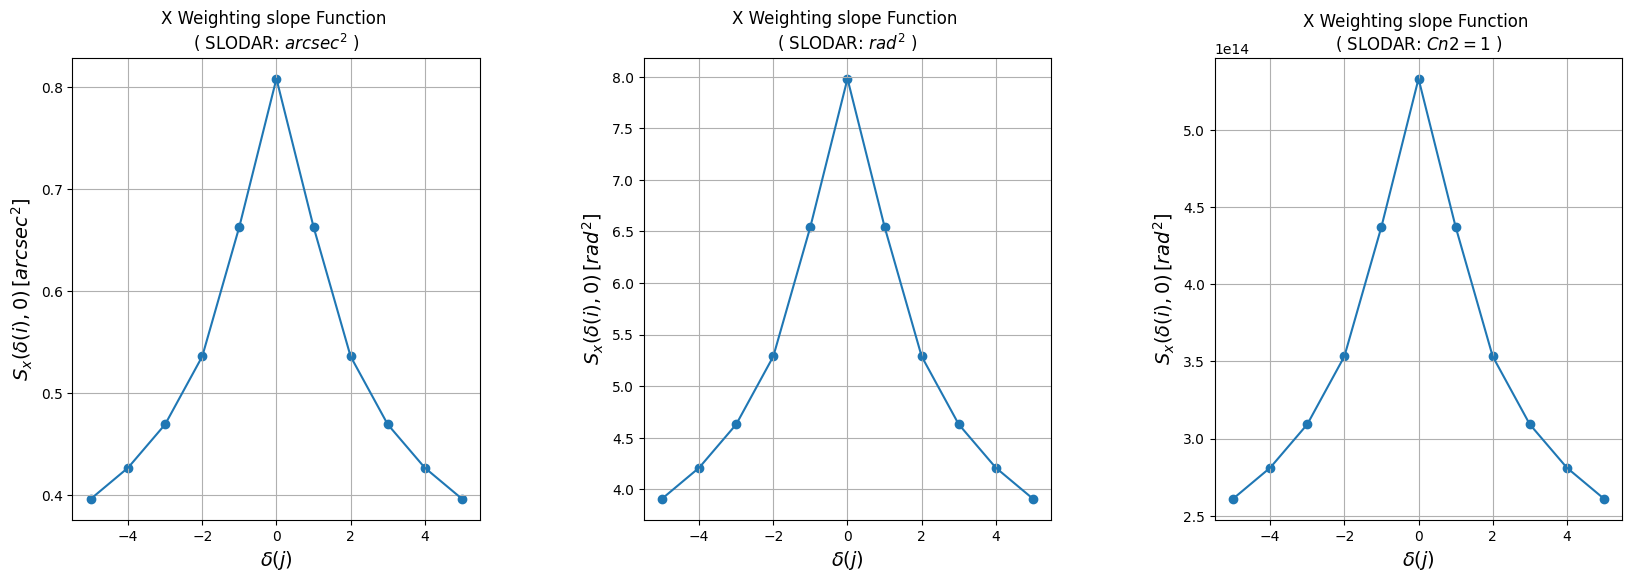

In [35]:
# SLODAR Function

import numpy as np
import matplotlib.pyplot as plt
from SLODAR import slopecov_kol
from aotools.turbulence import r0_to_cn2,cn2_to_r0
# --- Example params ---

d = 0.047                     # sub-aperture size
nsubx = 6                     # sub-apertures 
lamda = 500e-9                # lamda 
scalingRad =(np.pi)**2 # result Rad

## --- Result on arcsec2 ---
Arcov = slopecov_kol(nsubx, d, lamda, nsamp=8, scalingFactor=1, r0=1) 

## --- Result on rad2 ---
Radcov = slopecov_kol(nsubx, d, lamda, nsamp=8, scalingFactor=scalingRad, r0=1) 

## --- Result on scaling r0=1 to cn2=1 on rad2 ---
Cncov = slopecov_kol(nsubx, d, lamda, nsamp=8, scalingFactor=scalingRad, r0=cn2_to_r0(1,lamda)) 

GRID_SIZE = 2 * nsubx - 1
BEAM = 1


# --- graphs ---

fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.4)  

ax1 = fig.add_subplot(gs[0,0])
ax1.plot(np.arange(-5, 6),Arcov[0,:,5],)
ax1.scatter(np.arange(-5, 6),Arcov[0,:,5],)
ax1.set_title('X Weighting slope Function \n' + r'( SLODAR: $arcsec^2$ )')
ax1.set_ylabel(r'$S_x(\delta(i),0)\,[arcsec^2]$', fontsize=14)
ax1.set_xlabel(r'$\delta(j)$', fontsize=14)
ax1.grid("both")

ax2 = fig.add_subplot(gs[0,1])
ax2.plot(np.arange(-5, 6),Radcov[0,:,5],)
ax2.scatter(np.arange(-5, 6),Radcov[0,:,5],)
ax2.set_title('X Weighting slope Function \n' + r'( SLODAR: $rad^2$ )')
ax2.set_ylabel(r'$S_x(\delta(i),0)\,[rad^2]$', fontsize=14)
ax2.set_xlabel(r'$\delta(j)$', fontsize=14)
ax2.grid("both")


ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(np.arange(-5, 6),Cncov[0,:,5],)
ax3.scatter(np.arange(-5, 6),Cncov[0,:,5],)
ax3.set_title('X Weighting slope Function \n' + r'( SLODAR: $Cn2 = 1$ )')
ax3.set_ylabel(r'$S_x(\delta(i),0)\,[rad^2]$', fontsize=14)
ax3.set_xlabel(r'$\delta(j)$', fontsize=14)
ax3.grid("both")


# Z-tilt filter method: In this section, may be dragons.

---

**@dev_note:** This is one of the most problematic sections. I am currently investigating the behavior of the different variables involved. Some adjustments have resolved specific issues (many thanks Ryan); however, new ones have emerged. The root cause is still unclear, as demonstrated in this section.


Text(0, 0.5, '$\\delta(j)$')

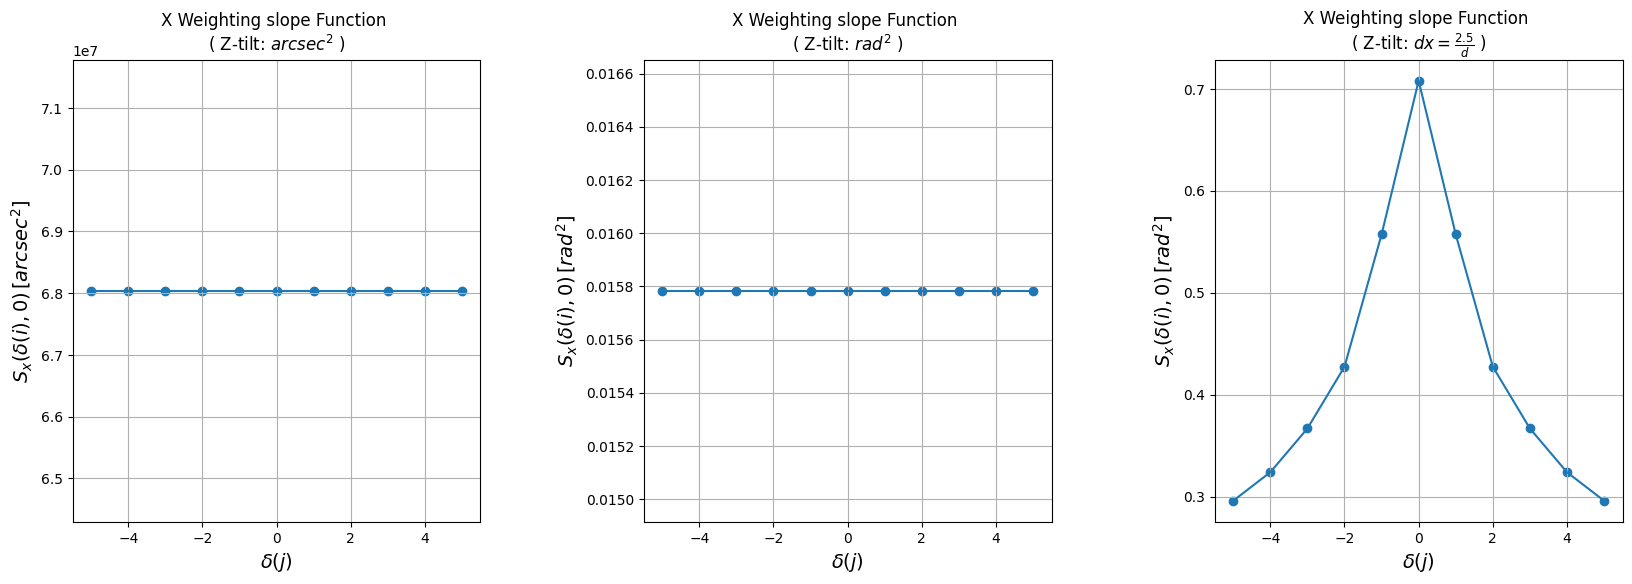

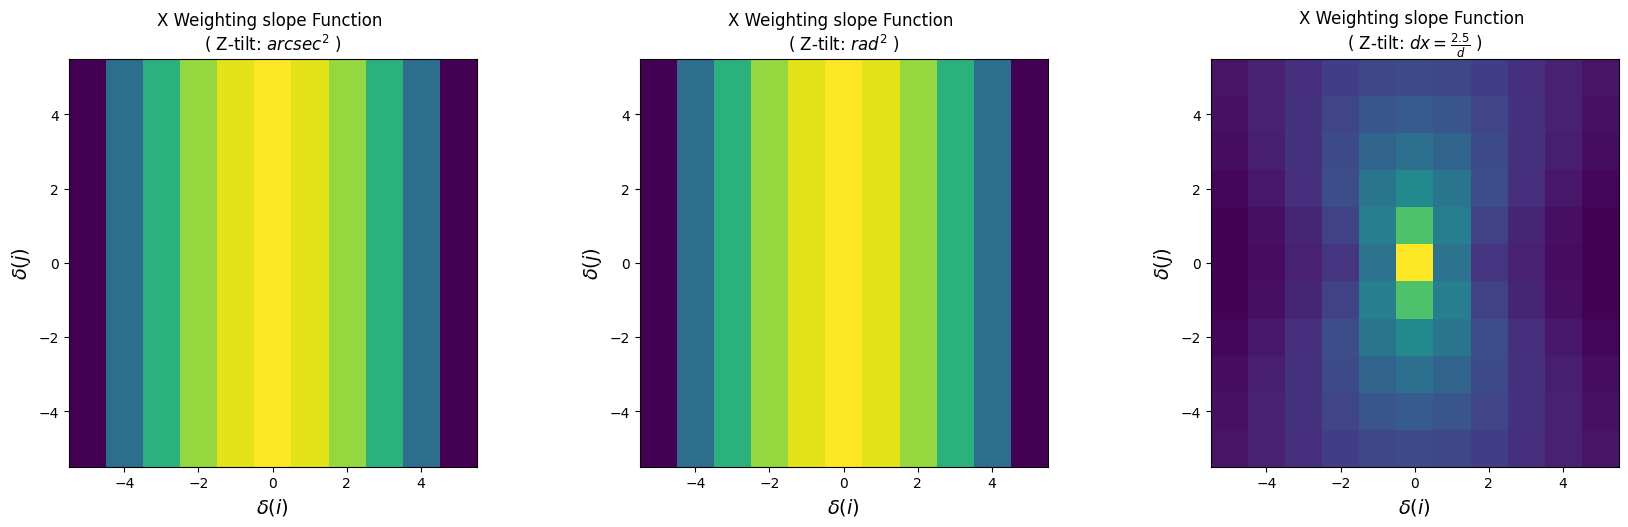

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from Zfilter import weighting_function
# --- Example params ---

d = 0.047                     # sub-aperture size
nsubx = 6                     # sub-apertures 
lamda = 500e-9                # lamda 
scalingArcsec = (206265.0/np.pi)**2 # result on arcsec
samp = 1024                   # sampling > 256
cn2r0 = 1                     # Cn2 or R0
dx = 0.5 * d / samp           # 1/(dx * samp) = df = 2/d (this is one of the most problematic variable)  


## --- Result on arcsec2 ---
Arcov = weighting_function(d, dx, nsubx, samp, cn2r0=cn2r0, wavelength=lamda, scalingFactor=scalingArcsec, glob = False)

## --- Result on rad2 ---
Radcov = weighting_function(d, dx, nsubx, samp, cn2r0=cn2r0, wavelength=lamda, scalingFactor=1, glob = False)

## --- dx = 2.5 / d ---
Dxcov = weighting_function(d, 2.5 / d, nsubx, samp, cn2r0=cn2r0, wavelength=lamda, scalingFactor=1, glob = False)

GRID_SIZE = nsubx*2 - 1  
BEAM = 1

# --- graphs ---

fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.4)  

ax1 = fig.add_subplot(gs[0,0])
ax1.plot(np.arange(-5, 6),Arcov[0,:,5],)
ax1.scatter(np.arange(-5, 6),Arcov[0,:,5],)
ax1.set_title('X Weighting slope Function \n' + r'( Z-tilt: $arcsec^2$ )')
ax1.set_ylabel(r'$S_x(\delta(i),0)\,[arcsec^2]$', fontsize=14)
ax1.set_xlabel(r'$\delta(j)$', fontsize=14)
ax1.grid("both")

ax2 = fig.add_subplot(gs[0,1])
ax2.plot(np.arange(-5, 6),Radcov[0,:,5],)
ax2.scatter(np.arange(-5, 6),Radcov[0,:,5],)
ax2.set_title('X Weighting slope Function \n' + r'( Z-tilt: $rad^2$ )')
ax2.set_ylabel(r'$S_x(\delta(i),0)\,[rad^2]$', fontsize=14)
ax2.set_xlabel(r'$\delta(j)$', fontsize=14)
ax2.grid("both")

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(np.arange(-5, 6),Dxcov[0,:,5],)
ax3.scatter(np.arange(-5, 6),Dxcov[0,:,5],)
ax3.set_title('X Weighting slope Function \n' + r'( Z-tilt: $dx = \frac{2.5}{d}  $ )')
ax3.set_ylabel(r'$S_x(\delta(i),0)\,[rad^2]$', fontsize=14)
ax3.set_xlabel(r'$\delta(j)$', fontsize=14)
ax3.grid("both")

fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.4)  

ax1 = fig.add_subplot(gs[0,0])
ax1.imshow(Arcov[0,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax1.set_title('X Weighting slope Function \n' + r'( Z-tilt: $arcsec^2$ )')
ax1.set_xlabel(r'$\delta(i)$', fontsize=14)
ax1.set_ylabel(r'$\delta(j)$', fontsize=14)

ax2 = fig.add_subplot(gs[0,1])
ax2.imshow(Radcov[0,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax2.set_title('X Weighting slope Function \n' + r'( Z-tilt: $rad^2$ )')
ax2.set_xlabel(r'$\delta(i)$', fontsize=14)
ax2.set_ylabel(r'$\delta(j)$', fontsize=14)

ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(Dxcov[0,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax3.set_title('X Weighting slope Function \n' + r'( Z-tilt: $dx = \frac{2.5}{d}  $ )')
ax3.set_xlabel(r'$\delta(i)$', fontsize=14)
ax3.set_ylabel(r'$\delta(j)$', fontsize=14)


## Observations:

---

In addition to the anomalous aspects observed in the section concerning the use of $df = 2/d$, there is also the fact that, for reasons that remain unclear, adopting $2.5/d$ as $dx$ leads the covariance function to provide a better fit to the matrix generated by the Butterley algorithm. Moreover, somewhat unexpectedly, even when the covariance is expressed in $\mathrm{rad}^2$, it still matches the function reported in the Butterley section, which is given in $\mathrm{arcsec}^2$. A comparison with the tip/tilt extraction algorithm will be presented in a later section.

Returning to the main point, when adopting $df = 2/d$ and examining the corresponding expression, several unusual features become apparent:

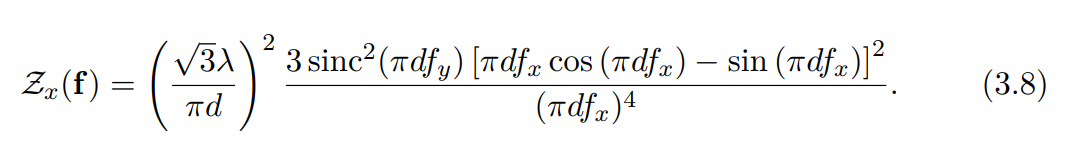

When adopting $df = 2/d$, the argument of the $\mathrm{sinc}(\cdot)$ function undergoes a direct simplification, such that all frequency components become integer multiples of $2\pi$. Consequently, the $\mathrm{sinc}$ term vanishes, driving the entire expression to zero.

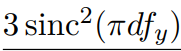

This may explain why the first two covariance matrices exhibit essentially no covariance, or only a very weak signal.

It is also possible that I misinterpreted the term $df = 2/d$, and that it should instead be understood as $dx = 2/d$; however, this alternative interpretation still raises questions.


# G-tilt:

---

**@dev_note:** This section exhibits fewer issues than the others. After replacing the scaling factor $\left(\frac{\lambda}{2\pi}\right)^2$ with $\lambda^2$, most of the problems were resolved. Although this modification may stem from a misinterpretation on my part, the dimensional analysis supports the change in units.

The behavior of this function is otherwise identical to that of the Z-tilt case, with the only modification being the aperture function, which is replaced by the expression shown below, together with the corresponding integration formula. Nevertheless, a noteworthy peculiarity remains: it produces the same covariance matrix as the Z-tilt formulation. This becomes more evident in the comparison with tip/tilt subtraction.

Aperture function:

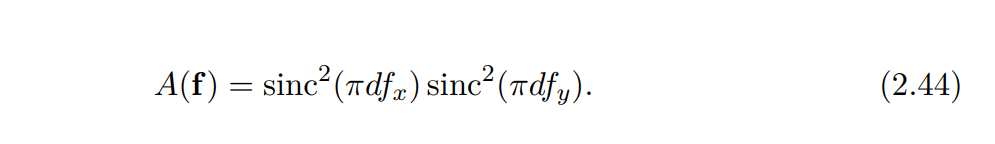

Covariance matrix:

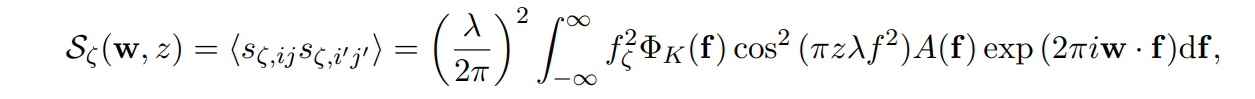


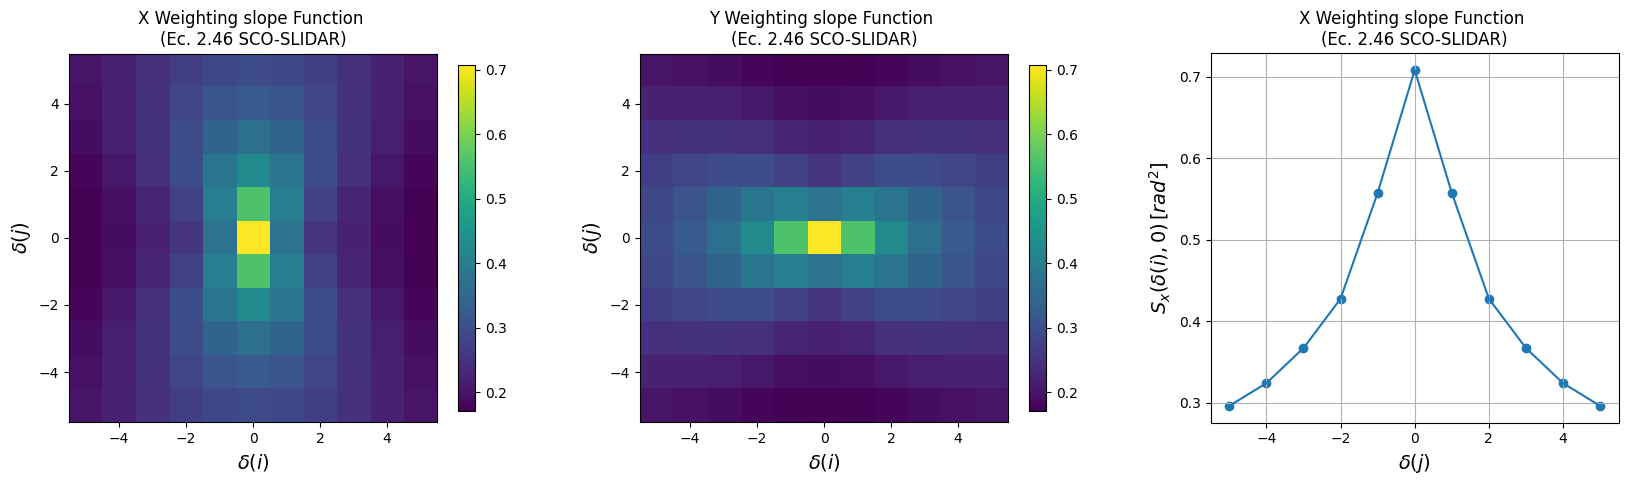

In [4]:
from Gfilter import slope_weighting_function
import matplotlib.pyplot as plt
import numpy as np

# --- Example params ---

d = 0.047   # sub-aperture size
nsubx = 6   # sub-apertures 
samp = 1024    # sampling
r0 = 1

tcov = slope_weighting_function(d, 2.5/d, nsubx, samp, cn2r0=r0, wavelength=500e-9, glob = False)

GRID_SIZE = 2 * nsubx - 1
BEAM = 1

# --- graphs ---

fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.4)  

ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(tcov[0,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax1.set_title('X Weighting slope Function \n(Ec. 2.46 SCO-SLIDAR)')
ax1.set_xlabel(r'$\delta(i)$', fontsize=14)
ax1.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im1, ax=ax1, shrink=0.75, fraction=0.046)

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(tcov[1,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax2.set_title('Y Weighting slope Function \n(Ec. 2.46 SCO-SLIDAR)')
ax2.set_xlabel(r'$\delta(i)$', fontsize=14)
ax2.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im2, ax=ax2, shrink=0.75, fraction=0.046)

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(np.arange(-5, 6),tcov[0,:,5],)
ax3.scatter(np.arange(-5, 6),tcov[0,:,5],)
ax3.set_title('X Weighting slope Function \n(Ec. 2.46 SCO-SLIDAR)')
ax3.set_ylabel(r'$S_x(\delta(i),0)\,[rad^2]$', fontsize=14)
ax3.set_xlabel(r'$\delta(j)$', fontsize=14)
ax3.grid("on")

pos = ax3.get_position()
ax3.set_position([pos.x0, pos.y0 + pos.height*0.1, pos.width, pos.height*0.8])

# Tip-tilt Substraction(based on Butterley code):


In [5]:
def ref_funcs_2d(cov: np.ndarray, pupil_mask: np.ndarray):
    """
    Replica la idea de slodar_refFuncs2D():
      - Proyecta cov a pares de sub-aperturas activas según pupil_mask
      - Aplica tip/tilt subtraction en la matriz de covarianza proyectada
      - Re-binea de vuelta a un mapa 2D por separación (nn x nn) promediando
    """
    nsubx = pupil_mask.shape[0]
    nn = 2 * nsubx - 1

    # índices de sub-aperturas activas
    active = [(i, j) for j in range(nsubx) for i in range(nsubx) if pupil_mask[j, i] > 0]
    nsubtot = len(active)

    psfs = np.zeros((2, nn, nn), dtype=np.float64)

    # pcov: matriz completa (nsubtot x nsubtot) para x e y intercalados
    pcov = np.zeros((nsubtot, nsubtot, 2), dtype=np.float64)

    # 1) llenar pcov tomando valores desde cov[2*delta] (x) y cov[2*delta+1] (y)
    for a, (i1, j1) in enumerate(active):
        for b, (i2, j2) in enumerate(active):
            di = i2 - i1 + (nsubx - 1)
            dj = j2 - j1 + (nsubx - 1)
            pcov[a, b, 0] = cov[1, di, dj]
            pcov[a, b, 1] = cov[0, di, dj]

    # 2) tip/tilt subtraction: C' = C - rowMean - colMean + globalMean
    row_mean = pcov.mean(axis=1, keepdims=True)   # (nsubtot,1,2)
    col_mean = pcov.mean(axis=0, keepdims=True)   # (1,nsubtot,2)
    glob_mean = pcov.mean(axis=(0, 1), keepdims=True)  # (1,1,2)
    pcov2 = pcov - row_mean - col_mean + glob_mean

    # 3) rebin a separaciones (nn x nn) 
    acc = np.zeros((nn, nn, 2), dtype=np.float64)
    cnt = np.zeros((nn, nn), dtype=np.int64)

    for a, (i1, j1) in enumerate(active):
        for b, (i2, j2) in enumerate(active):
            di = i2 - i1 + (nsubx - 1)
            dj = j2 - j1 + (nsubx - 1)

            acc[di, dj, :] += pcov2[a, b, :]
            cnt[di, dj] += 1

    # cnt>0
    m = cnt > 0
    psfs[0, m] = (acc[m, 0] / cnt[m])
    psfs[1, m] = (acc[m, 1] / cnt[m])

    return psfs

# Tip/Tilt Subtraction with Known Matrices

At this stage, I understand that this part should ideally not be carried out until the issues discussed in the previous sections have been resolved. Nevertheless, it is still pursued here, since it is necessary to verify that the code is functioning correctly.

Additionally, for Butterley’s integral method, we used only $\lambda = 500\,\mathrm{nm}$. The integral approach and its associated scaling factor depend strongly on the wavelength. Interestingly, the Z-tilt/G-tilt approach does not depend as critically on this scaling factor; in fact, it has been verified that these covariance matrices are independent of the wavelength assigned.

In this case, I consider two known functions. Their corresponding plots and citations are provided below:

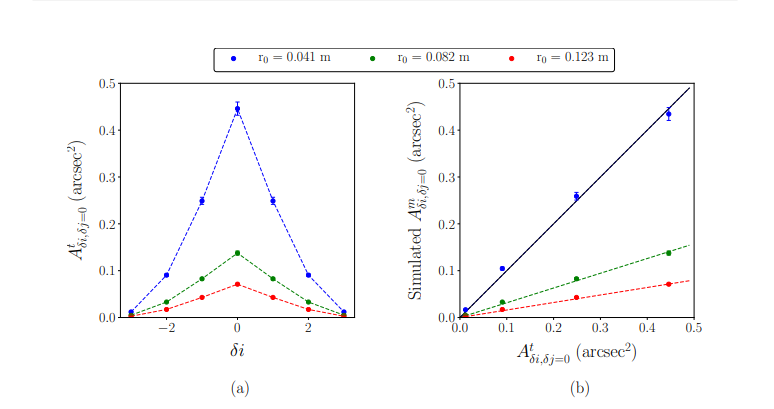

ref: Saavidra Perera, R. W. Wilson, T. Butterley, J. Osborn, O. J. D. Farley, and D. J. Laidlaw, “SHIMM: a versatile seeing monitor for astronomy,” Monthly Notices of the Royal Astronomical Society, vol. 523, no. 4, pp. 5745–5758, Aug. 2023, doi: 10.1093/mnras/stad1339.

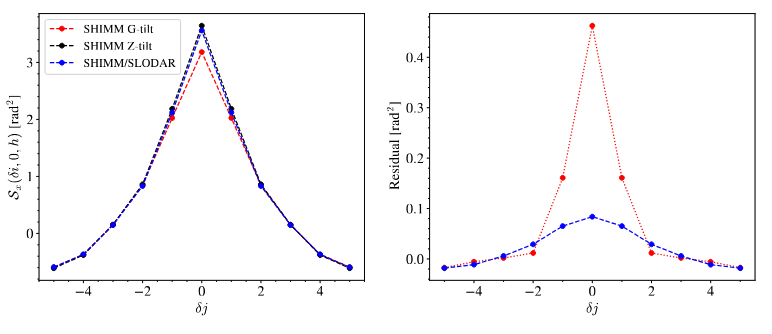

ref:R. M. Griffiths, Continuous 24-hour Shack-Hartmann optical turbulence profiling on a small telescope, Durham University, Durham E-Theses, 2024. [Online].


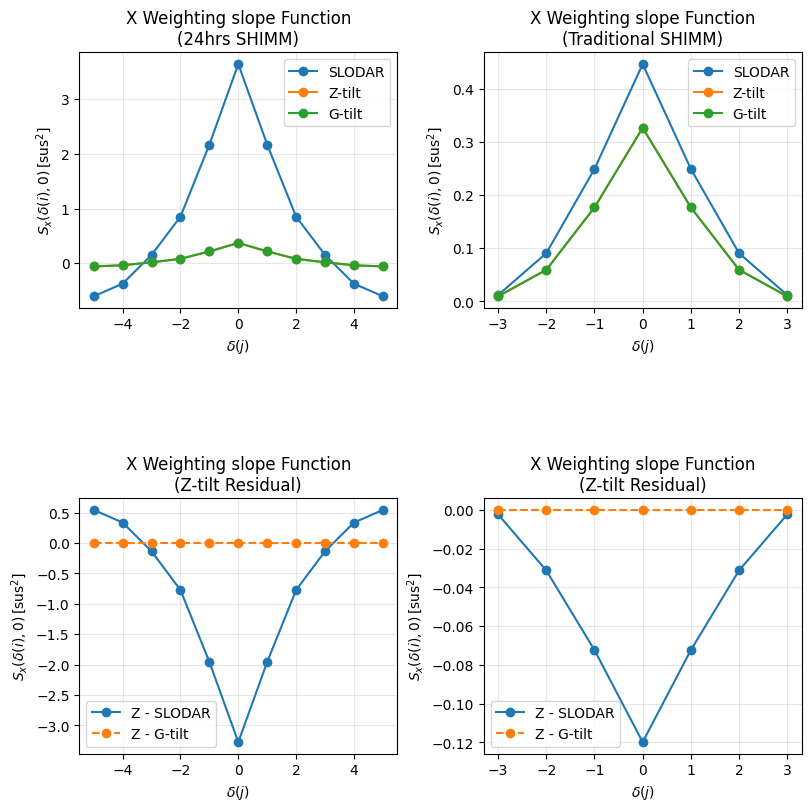

In [36]:

from SLODAR import slopecov_kol
from Gfilter import slope_weighting_function
from Zfilter import weighting_function
import matplotlib.pyplot as plt
import numpy as np

nsubx = 6       
sampling = 1024

# --- 24hrs SHIMM matrix data ---
Rlamda = 1280e-9
Rd = 0.047       # subaperture size
Rcn2 = 1
Rdx = 2.5/Rd
Rpupil =  np.array([[0,0,1,1,0,0],
                   [0,1,1,1,1,0],
                   [1,1,0,0,1,1],
                   [1,1,0,0,1,1],
                   [0,1,1,1,1,0],
                   [0,0,1,1,0,0]])

# --- Traditional SHIMM C9 paper matrix data ---
Tlamda = 500e-9
Tcn2 = 1
Td = 0.041      # subaperture size
Tdx = 2.5/Td
Tpupil = np.array([[0,0,0,0,0,0],
                   [0,1,1,1,1,0],
                   [0,1,0,0,1,0],
                   [0,1,0,0,1,0],
                   [0,1,1,1,1,0],
                   [0,0,0,0,0,0]])


# --- 24hrs SHIMM ---
tcov = slopecov_kol(nsubx, Rd, 500e-9,r0=1,scalingFactor=np.pi**2 ) #<-- Rad2
Zcov = weighting_function(Rd, Rdx, nsubx, sampling, scalingFactor=1 ,cn2r0=Rcn2, wavelength=Rlamda, glob=False)
Gcov = slope_weighting_function(Rd, Rdx, nsubx, sampling, scalingFactor=1 ,cn2r0=Rcn2, wavelength=Rlamda, glob=False)

RBpsfs = ref_funcs_2d(tcov,Rpupil) # Butterley function
RZpsfs = ref_funcs_2d(Zcov,Rpupil) # Z-tilt function
RGpsfs = ref_funcs_2d(Gcov,Rpupil) # G-tilt function


# --- Traditional SHIMM ---
tcov = slopecov_kol(nsubx, Td, 500e-9,r0=1,scalingFactor=1 ) #<-- Arcsec2 
Zcov = weighting_function(Td, Tdx, nsubx, sampling, scalingFactor=1 ,cn2r0=Tcn2, wavelength=Tlamda, glob=False)
Gcov = slope_weighting_function(Td, Tdx, nsubx, sampling, scalingFactor=1 ,cn2r0=Tcn2, wavelength=Tlamda, glob=False)

TBpsfs = ref_funcs_2d(tcov,Tpupil) # Butterley function
TZpsfs = ref_funcs_2d(Zcov,Tpupil) # Z-tilt function
TGpsfs = ref_funcs_2d(Gcov,Tpupil) # G-tilt function



GRID_SIZE = 2 * nsubx - 1 
BEAM = 1

# --- graphs ---
fig = plt.figure(figsize=(8, 8), constrained_layout=True)  # más alto
gs = fig.add_gridspec(2, 2, wspace=0., hspace=0.25)       # menos espacio

ax1 = fig.add_subplot(gs[0,0])
x1 = np.arange(-5, 6)
ax1.plot(x1, RBpsfs[0,5,:], marker="o", label="SLODAR")
ax1.plot(x1, RZpsfs[0,5,:], marker="o", label="Z-tilt")
ax1.plot(x1, RGpsfs[0,5,:], marker="o", label="G-tilt")
ax1.set_title('X Weighting slope Function\n(24hrs SHIMM)')
ax1.set_ylabel(r'$S_x(\delta(i),0)\,[\mathrm{sus}^2]$')
ax1.set_xlabel(r'$\delta(j)$')
ax1.grid(True, which="both", alpha=0.3)
ax1.legend()

ax2 = fig.add_subplot(gs[0,1])
x2 = np.arange(-3, 4)
ax2.plot(x2, TBpsfs[0,5,2:9], marker="o", label="SLODAR")
ax2.plot(x2, TZpsfs[0,5,2:9], marker="o", label="Z-tilt")
ax2.plot(x2, TGpsfs[0,5,2:9], marker="o", label="G-tilt")
ax2.set_title('X Weighting slope Function\n(Traditional SHIMM)')
ax2.set_ylabel(r'$S_x(\delta(i),0)\,[\mathrm{sus}^2]$')
ax2.set_xlabel(r'$\delta(j)$')
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()

ax3 = fig.add_subplot(gs[1,0])
ax3.plot(x1, RZpsfs[0,5,:]-RBpsfs[0,5,:], marker="o", label="Z - SLODAR")
ax3.plot(x1, RZpsfs[0,5,:]-RGpsfs[0,5,:], "--", marker="o", label="Z - G-tilt")
ax3.set_title('X Weighting slope Function\n(Z-tilt Residual)')
ax3.set_ylabel(r'$S_x(\delta(i),0)\,[\mathrm{sus}^2]$')
ax3.set_xlabel(r'$\delta(j)$')
ax3.grid(True, which="both", alpha=0.3)
ax3.legend()

ax4 = fig.add_subplot(gs[1,1])
ax4.plot(x2, TZpsfs[0,5,2:9]-TBpsfs[0,5,2:9], marker="o", label="Z - SLODAR")
ax4.plot(x2, TZpsfs[0,5,2:9]-TGpsfs[0,5,2:9], "--", marker="o", label="Z - G-tilt")
ax4.set_title('X Weighting slope Function\n(Z-tilt Residual)')
ax4.set_ylabel(r'$S_x(\delta(i),0)\,[\mathrm{sus}^2]$')
ax4.set_xlabel(r'$\delta(j)$')
ax4.grid(True, which="both", alpha=0.3)
ax4.legend()


# Conclusion:

The traditional SLODAR formulation is the one that most closely matches the reference functions, at least for the conventional SHIMM case expressed in $\mathrm{arcsec}^2$, and also in $\mathrm{rad}^2$ for the plot provided by Ryan. This agreement indicates that the tip/tilt subtraction code is functioning correctly.

However, the unit handling in the Z-tilt and G-tilt formulations is still not fully consistent. At this point, it remains necessary to determine the appropriate value of $dx$ and to understand why, despite employing different aperture functions, their resulting curves remain so similar, which should not be the case. Finally, when rescaling the traditional SLODAR function to $C_n^2 = 1$, the resulting values increased dramatically.
